# Energy Consumption Forecasting v2
### Meter FUTU0000000004000002 | 1-hour intervals | 7-day horizon

> **Why 7 days?** Prior experiments showed prediction error grows sharply beyond 7 days. A 7-day window
> balances accuracy (~30% daily MAPE) with operational utility (shift scheduling, maintenance planning).
> It can be re-run weekly for a rolling forecast.

**Architecture**: Two-Stage XGBoost (classifier + regressor) → DOW hourly profile decomposition

This architecture was arrived at after 10+ iterations. Key lessons that shaped it:
- A single regressor cannot handle the **bimodal distribution** (active vs shutdown days)
- **Recursive lag features** at the daily level caused +67% error via error propagation
- **Soft blending** of classifier probabilities crushed weekend/holiday predictions
- 3 coarse day-type profiles (working/weekend/holiday) lost Mon-Fri shape differences
- An hourly correction model **overfit** with current data volume

| Component | Purpose | Impact |
|---|---|---|
| Stage 1 — XGBClassifier | Predict if a day is active (≥50 kWh) vs shutdown | Prevents the regressor from being confused by zero-consumption days |
| Stage 2 — XGBRegressor | Predict consumption magnitude (active days only) | Trains on a cleaner, unimodal distribution → lower MAE |
| DOW Profiles (7) | Decompose daily totals into 24 hourly values | Captures Mon≠Tue≠…≠Sun hourly shapes (e.g., Fri ramp-down differs from Mon ramp-up) |
| Recency Scaling | Adjust predictions using last 30 active days vs full-history mean | Compensates for recent consumption trends without adding lag features |
| Short-term XGBoost | 1-step recursive for immediate 1-6h forecasts | Leverages real lag data for near-term accuracy; blends to daily model beyond 6h |

## Section 1 — Data Loading (MongoDB)
Load raw meter readings from MongoDB. The data is ~1-minute resolution kWh readings
(`A1` column) for a single energy meter, spanning Oct 2024 – Apr 2026 (~980K rows).
Each row is the cumulative energy meter reading (total kWh consumed to date) at that minute.
Sorting by `_id DESC` retrieves newest records first (reversed later during cleaning).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
import joblib
import os
from datetime import timedelta

from pymongo import MongoClient, DESCENDING
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

MONGO_URI = "string"
DB_NAME = "IOTDeviceMonitor"
COLLECTION = "FUTU00_DataMonitor"
METER_ID = "FUTU0000000004000002"
MODEL_DIR = r"E:\Projects\IOT-AI-Implementation\models\MODEL02_v2"
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Thresholds (tuned across 10+ iterations) ---
SHUTDOWN_THRESH = 50        # kWh/day — bimodal split point; days below this are "shutdown"
ACTIVE_HOUR_THRESH = 5.0    # kWh — excludes near-zero hours from MAPE to avoid divide-by-noise inflation
PROB_THRESH = 0.15          # Hard cutoff for P(active); soft blending crushed weekend/holiday predictions
RECENT_WINDOW = 30          # Days for recency scaling — balances stability vs responsiveness to recent trends
FORECAST_DAYS = 7           # 7-day horizon — error grows sharply beyond this; aligns with weekly ops planning
MIN_DAYS_FOR_DOW = 4        # DOW profiles need ≥4 samples; sparse DOWs fall back to coarser day-type profiles

In [3]:
client = MongoClient(MONGO_URI)
db = client[DB_NAME]
collection = db[COLLECTION]

query = {"EnergymeterId": METER_ID}
cursor = collection.find(query).sort("_id", DESCENDING)
raw = list(cursor)

df_raw = pd.DataFrame(raw)
print(f"Raw shape: {df_raw.shape}")
print(f"Columns : {list(df_raw.columns)}")
df_raw.head(5)

Raw shape: (980984, 6)
Columns : ['_id', 'UID', 'RTC', 'A1', 'EnergymeterId', 'timestamp']


,_id,UID,RTC,A1,EnergymeterId,timestamp
0,69d8c5a49f2e531fa0d682eb,02,2026-04-10 08:08:00,345252.6400,FUTU0000000004000002,10-04-2026 15:10:52
1,69d8c56c9f2e531fa0d67d37,02,2026-04-10 08:07:00,345252.5600,FUTU0000000004000002,10-04-2026 15:09:56
2,69d8c52c9f2e531fa0d676f5,02,2026-04-10 08:06:00,345252.5200,FUTU0000000004000002,10-04-2026 15:08:52
3,69d8c4f09f2e531fa0d6736d,02,2026-04-10 08:05:00,345252.4800,FUTU0000000004000002,10-04-2026 15:07:52
4,69d8c4b49f2e531fa0d66fc3,02,2026-04-10 08:04:00,345252.4800,FUTU0000000004000002,10-04-2026 15:06:52


## Section 2 — Cleaning & Resampling to 1-hour

**Steps & their impact:**
1. **Rename columns** → human-readable names (`A1`→`total_kwh`, `RTC`→`rtc_timestamp`)
2. **Type coercion** → ensures numeric/datetime types; drops unparseable rows
3. **Zero removal** → meter readings of exactly 0 indicate faulty readings, not real consumption
4. **Resample to 1h** via `mean()` → reduces ~980K rows to ~13K rows; smooths out sub-minute noise
5. **consumption_kwh = diff(total_kwh).clip(≥0)** → converts cumulative meter readings to hourly consumption; clip prevents negative values from meter resets

In [5]:
df = df_raw.copy()

# Step 1: Rename raw MongoDB field names to meaningful column names
df = df.rename(columns={
    "A1": "total_kwh",           # cumulative energy meter reading (total kWh consumed to date)
    "RTC": "rtc_timestamp",      # meter's real-time clock timestamp
    "EnergymeterId": "meter_id",
})

# Step 2: Sort chronologically (MongoDB query returned DESC order)
df = df.sort_values(["meter_id", "rtc_timestamp"])

# Step 3: Coerce types — invalid entries become NaN and are dropped
df["total_kwh"] = pd.to_numeric(df["total_kwh"], errors="coerce")
df["rtc_timestamp"] = pd.to_datetime(df["rtc_timestamp"], errors="coerce")
df = df.dropna(subset=["rtc_timestamp", "total_kwh"])

# Step 4: Remove exact-zero meter readings (faulty sensor reads, not real zero consumption)
df.loc[df["total_kwh"] == 0, "total_kwh"] = np.nan
df = df.dropna()

# Step 5: Resample ~1-min data to 1-hour using mean of cumulative readings within each hour
# Impact: ~980K rows → ~13K rows; reduces noise while preserving consumption patterns
df = (
    df.set_index("rtc_timestamp")
      .resample("1h")["total_kwh"]
      .mean()
      .reset_index()
)

# Step 6: Derive hourly consumption from cumulative meter reading
# diff() gives hourly delta; clip(lower=0) handles rare meter resets/rollbacks
df["consumption_kwh"] = df["total_kwh"].diff().clip(lower=0)
df.loc[df["consumption_kwh"].isna(), "consumption_kwh"] = 0  # first row has no previous value

print(f"Hourly rows : {len(df):,}")
print(f"Date range  : {df['rtc_timestamp'].min()} → {df['rtc_timestamp'].max()}")
print(f"\nConsumption stats:\n{df['consumption_kwh'].describe().to_string()}")

Hourly rows : 12,989
Date range  : 2024-10-16 04:00:00 → 2026-04-10 08:00:00

Consumption stats:
count    12989.000000
mean        19.570873
std         12.161099
min          0.000000
25%         11.518388
50%         21.993756
75%         27.919964
max         63.685547


## Section 3 — EDA & Pattern Analysis

**Goal**: Understand the data's structure before modeling. Key things to verify:
- **Bimodal distribution** — confirms the need for a two-stage (classifier + regressor) approach
- **DOW patterns** — reveals that Mon-Fri and Sat-Sun have distinctly different consumption levels
- **Monthly seasonality** — identifies if certain months have higher/lower usage
- **Hourly profile** — shows the intra-day consumption shape (peaks, valleys)
- **Shutdown frequency** — quantifies how often each DOW sees complete shutdowns

Active days: 485 | Shutdown days: 57 (10.5%)


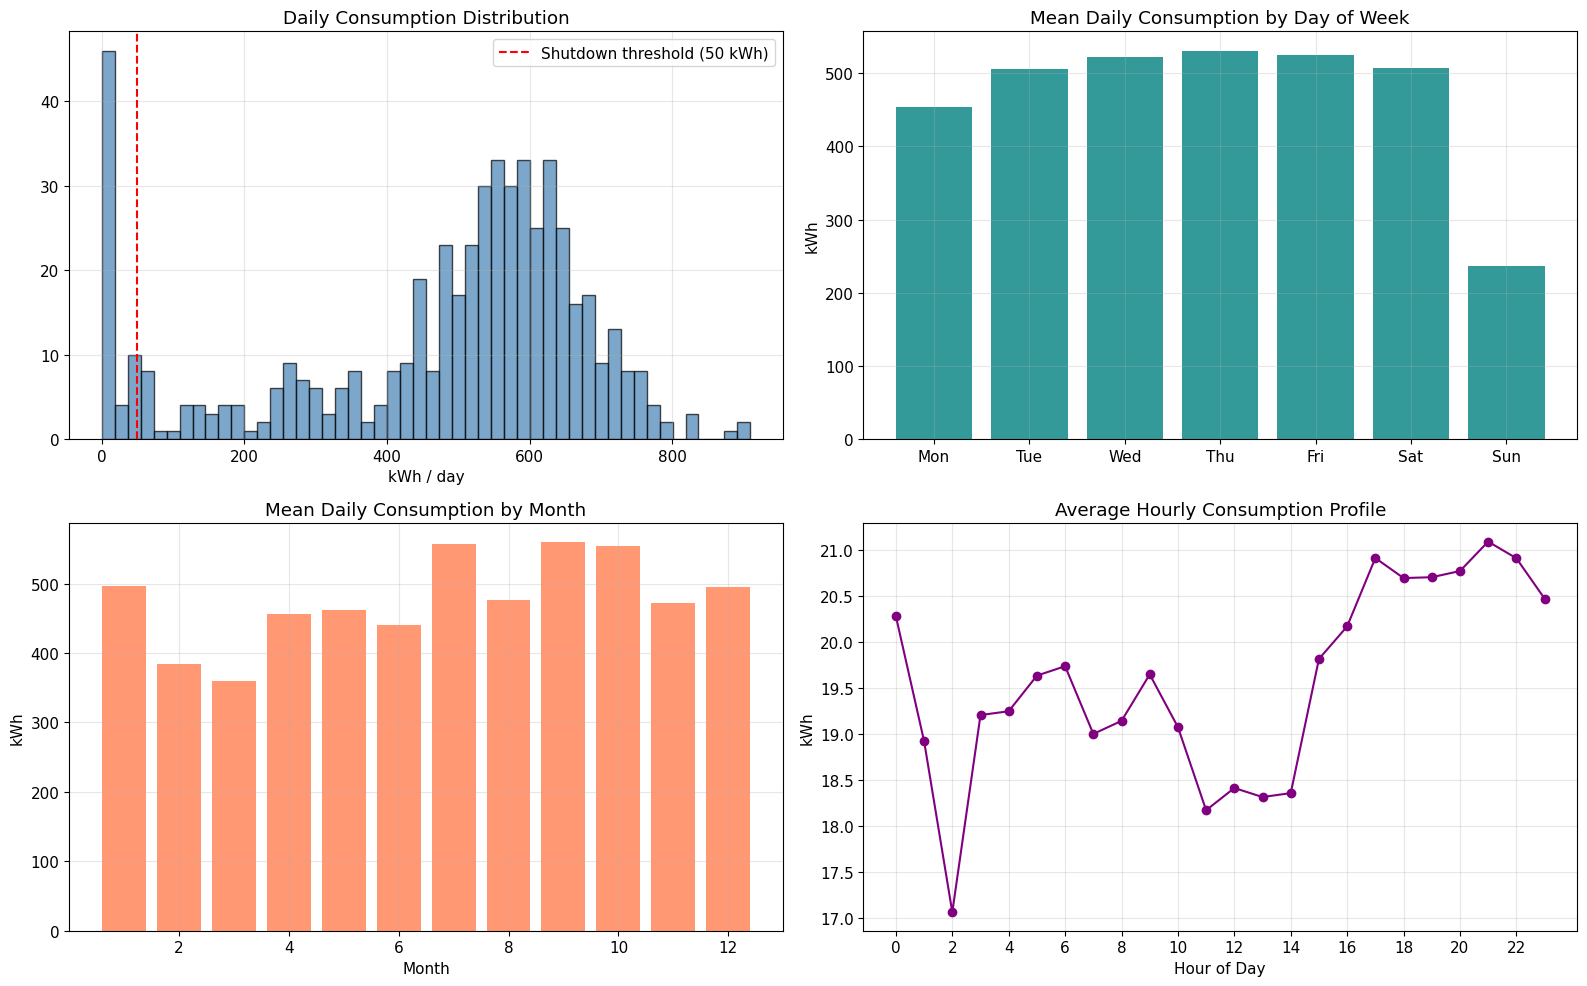

In [6]:
# Aggregate hourly consumption to daily totals for distribution analysis
daily = df.set_index("rtc_timestamp")["consumption_kwh"].resample("1D").sum().reset_index()
daily.columns = ["date", "daily_kwh"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 3a — Bimodal histogram: the two peaks (near-zero and ~400-600 kWh) justify the two-stage model
axes[0, 0].hist(daily["daily_kwh"], bins=50, edgecolor="k", alpha=0.7, color="steelblue")
axes[0, 0].axvline(SHUTDOWN_THRESH, color="red", ls="--", label=f"Shutdown threshold ({SHUTDOWN_THRESH} kWh)")
axes[0, 0].set_title("Daily Consumption Distribution")
axes[0, 0].set_xlabel("kWh / day")
axes[0, 0].legend()

n_active = (daily["daily_kwh"] >= SHUTDOWN_THRESH).sum()
n_shutdown = (daily["daily_kwh"] < SHUTDOWN_THRESH).sum()
print(f"Active days: {n_active} | Shutdown days: {n_shutdown} ({n_shutdown / len(daily) * 100:.1f}%)")

# 3b — DOW pattern: weekends typically lower → informs classifier and DOW profile strategy
daily["dow"] = pd.to_datetime(daily["date"]).dt.dayofweek
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_means = daily.groupby("dow")["daily_kwh"].mean()
axes[0, 1].bar(range(7), dow_means.values, color="teal", alpha=0.8)
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(dow_names)
axes[0, 1].set_title("Mean Daily Consumption by Day of Week")
axes[0, 1].set_ylabel("kWh")

# 3c — Monthly seasonality: identifies months with higher/lower baseline (e.g., summer AC load)
daily["month"] = pd.to_datetime(daily["date"]).dt.month
month_means = daily.groupby("month")["daily_kwh"].mean()
axes[1, 0].bar(month_means.index, month_means.values, color="coral", alpha=0.8)
axes[1, 0].set_title("Mean Daily Consumption by Month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("kWh")

# 3d — Hourly shape: reveals intra-day consumption curve used later for DOW profile decomposition
hourly_avg = df.groupby(df["rtc_timestamp"].dt.hour)["consumption_kwh"].mean()
axes[1, 1].plot(hourly_avg.index, hourly_avg.values, marker="o", color="purple")
axes[1, 1].set_title("Average Hourly Consumption Profile")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].set_ylabel("kWh")
axes[1, 1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

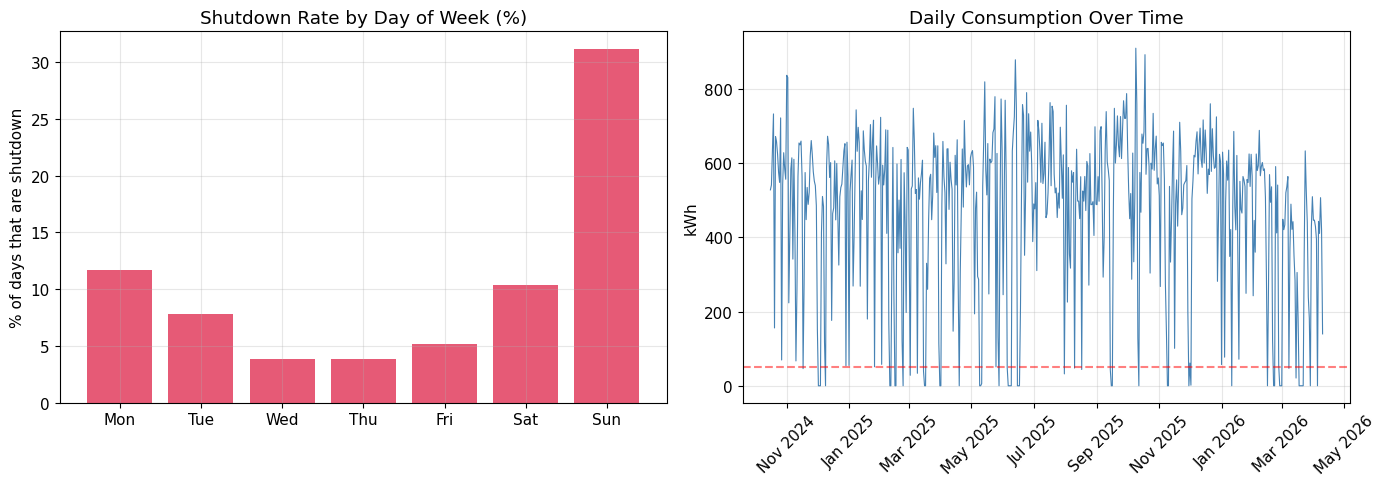

In [7]:
# Shutdown frequency by DOW — reveals which days are most likely to be off (e.g., Sundays)
# Impact: informs the classifier's scale_pos_weight and validates the P(active) threshold choice
shutdown_mask = daily["daily_kwh"] < SHUTDOWN_THRESH
shutdown_by_dow = daily[shutdown_mask].groupby("dow").size()
total_by_dow = daily.groupby("dow").size()
shutdown_rate = (shutdown_by_dow / total_by_dow * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(7), shutdown_rate.reindex(range(7), fill_value=0).values,
            color="crimson", alpha=0.7)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_names)
axes[0].set_title("Shutdown Rate by Day of Week (%)")
axes[0].set_ylabel("% of days that are shutdown")

# Daily consumption time series
axes[1].plot(daily["date"], daily["daily_kwh"], lw=0.8, color="steelblue")
axes[1].axhline(SHUTDOWN_THRESH, color="red", ls="--", alpha=0.5)
axes[1].set_title("Daily Consumption Over Time")
axes[1].set_ylabel("kWh")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Section 4 — Feature Engineering

Features are grouped into **5 categories**, each capturing a different aspect of energy patterns:

| Category | Features | Why it matters |
|---|---|---|
| **Calendar** | `is_holiday`, `is_weekend`, `is_working_day`, `is_working_hour`, `days_to_next_holiday` | Gujarat public holidays and weekends drive shutdowns; working hours have distinct load |
| **Temporal (cyclical)** | `hour_sin/cos`, `dow_sin/cos`, `mon_sin/cos`, `day_of_month` | Sin/cos encoding prevents 23→0 discontinuity; tree models can still split on raw values |
| **Shift pattern** | `shift` (0/1/2), `shift_sin/cos` | Captures 3-shift industrial operation (morning 06-14, afternoon 14-22, night 22-06) |
| **Shutdown tracking** | `hours_since_shutdown`, `just_restarted` | Ramp-up after shutdown differs from steady-state; captures restart transient |
| **Lag & rolling** | `cons_lag_1..168`, `kwh_lag_*`, rolling mean/std/max/min/range | Only used by the short-term hourly model (NOT the daily model — to avoid recursive error) |

> **Critical design choice**: The daily model uses ONLY calendar + temporal features (no lags).
> Prior experiments showed recursive lag features caused +67% monthly error through error propagation.

In [8]:
# Gujarat state holidays — the meter is in Gujarat; local holidays drive plant shutdowns
_gj_holidays = holidays.India(state="GJ", years=range(2023, 2028))

def build_features(frame):
    """Add all features to an hourly DataFrame (in-place).
    
    This function is also called during recursive forecasting (Section 10),
    so it must work on both full-history and single-row DataFrames.
    """
    ts = frame["rtc_timestamp"]

    # --- Calendar: primary drivers of active/shutdown classification ---
    frame["is_holiday"] = ts.dt.date.apply(lambda d: 1 if d in _gj_holidays else 0)
    frame["is_weekend"] = (ts.dt.dayofweek >= 5).astype(int)
    frame["is_working_day"] = ((frame["is_weekend"] == 0) & (frame["is_holiday"] == 0)).astype(int)
    frame["is_working_hour"] = (
        (ts.dt.hour >= 9) & (ts.dt.hour <= 18) & (frame["is_working_day"] == 1)
    ).astype(int)

    frame["days_to_next_holiday"] = ts.apply(
        lambda t: min((h - t.date()).days for h in _gj_holidays if (h - t.date()).days >= 0)
        if any((h - t.date()).days >= 0 for h in _gj_holidays) else 30
    ).clip(upper=30)

    # --- Temporal: cyclical encoding avoids the 23→0 / Dec→Jan discontinuity ---
    frame["hour_of_day"] = ts.dt.hour
    frame["dow"] = ts.dt.dayofweek
    frame["month"] = ts.dt.month
    frame["day_of_month"] = ts.dt.day

    frame["hour_sin"] = np.sin(2 * np.pi * frame["hour_of_day"] / 24)
    frame["hour_cos"] = np.cos(2 * np.pi * frame["hour_of_day"] / 24)
    frame["dow_sin"] = np.sin(2 * np.pi * frame["dow"] / 7)
    frame["dow_cos"] = np.cos(2 * np.pi * frame["dow"] / 7)
    frame["mon_sin"] = np.sin(2 * np.pi * frame["month"] / 12)
    frame["mon_cos"] = np.cos(2 * np.pi * frame["month"] / 12)

    # --- Shift pattern: captures industrial 3-shift operation ---
    def _shift(h):
        if 6 <= h < 14: return 1   # morning shift
        if 14 <= h < 22: return 2   # afternoon shift
        return 0                    # night / off-shift
    frame["shift"] = ts.dt.hour.apply(_shift)
    frame["shift_sin"] = np.sin(2 * np.pi * frame["shift"] / 3)
    frame["shift_cos"] = np.cos(2 * np.pi * frame["shift"] / 3)

    # --- Shutdown tracking: ramp-up after shutdown differs from steady-state ---
    # 0.5 kWh threshold distinguishes real zero from measurement noise
    frame["is_zero"] = (frame["consumption_kwh"] < 0.5).astype(int)
    _grp = (frame["is_zero"] != frame["is_zero"].shift()).cumsum()
    frame["hours_since_shutdown"] = frame.groupby(_grp).cumcount()
    frame.loc[frame["is_zero"] == 1, "hours_since_shutdown"] = 0
    frame["hours_since_shutdown"] = frame["hours_since_shutdown"].clip(upper=168)  # cap at 1 week
    # Restart flag — captures the transient spike when machines come back online
    frame["just_restarted"] = (
        (frame["is_zero"].shift(1) == 1) & (frame["is_zero"] == 0)
    ).astype(int)

    # --- Lag features: used ONLY by the short-term hourly model (Section 5 & 10) ---
    # These are NOT used by the daily model to avoid recursive error propagation
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        frame[f"cons_lag_{lag}"] = frame["consumption_kwh"].shift(lag)
        frame[f"kwh_lag_{lag}"] = frame["total_kwh"].shift(lag)

    # --- Rolling statistics: capture recent trend and volatility ---
    for win in [6, 12, 24]:
        frame[f"cons_roll_mean_{win}"] = frame["consumption_kwh"].rolling(win).mean()
        frame[f"kwh_roll_std_{win}"] = frame["total_kwh"].rolling(win).std()
    for win in [24, 168]:
        frame[f"rolling_max_{win}"] = frame["consumption_kwh"].rolling(win).max()
        frame[f"rolling_min_{win}"] = frame["consumption_kwh"].rolling(win).min()
        frame[f"rolling_range_{win}"] = frame[f"rolling_max_{win}"] - frame[f"rolling_min_{win}"]

    return frame

df = build_features(df)
df = df.dropna()  # drops first 168 rows (max lag window) — necessary for lag features to be valid

print(f"Feature-engineered rows: {len(df):,}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")

Feature-engineered rows: 11,075
Columns (52): ['rtc_timestamp', 'total_kwh', 'consumption_kwh', 'is_holiday', 'is_weekend', 'is_working_day', 'is_working_hour', 'days_to_next_holiday', 'hour_of_day', 'dow', 'month', 'day_of_month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'mon_sin', 'mon_cos', 'shift', 'shift_sin', 'shift_cos', 'is_zero', 'hours_since_shutdown', 'just_restarted', 'cons_lag_1', 'kwh_lag_1', 'cons_lag_2', 'kwh_lag_2', 'cons_lag_3', 'kwh_lag_3', 'cons_lag_6', 'kwh_lag_6', 'cons_lag_12', 'kwh_lag_12', 'cons_lag_24', 'kwh_lag_24', 'cons_lag_48', 'kwh_lag_48', 'cons_lag_168', 'kwh_lag_168', 'cons_roll_mean_6', 'kwh_roll_std_6', 'cons_roll_mean_12', 'kwh_roll_std_12', 'cons_roll_mean_24', 'kwh_roll_std_24', 'rolling_max_24', 'rolling_min_24', 'rolling_range_24', 'rolling_max_168', 'rolling_min_168', 'rolling_range_168']


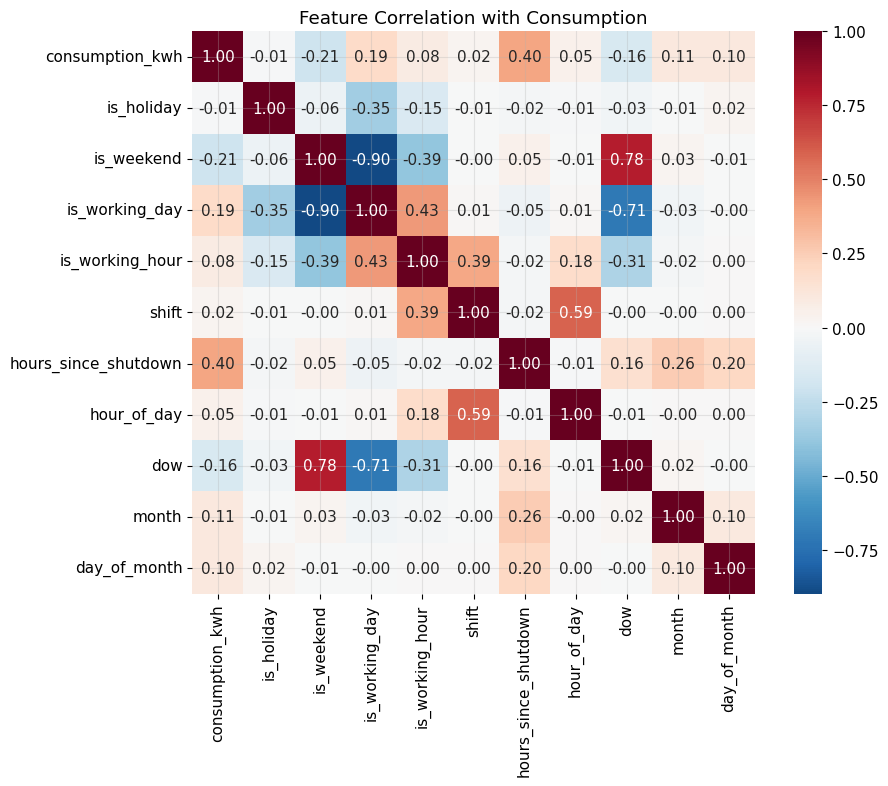

In [9]:
# Correlation heatmap — validates which calendar features have meaningful linear
# relationship with consumption. High |corr| features are likely important for the daily model.
# Note: XGBoost captures non-linear relationships too, so low linear corr ≠ low importance.
cal_cols = [
    "consumption_kwh", "is_holiday", "is_weekend", "is_working_day",
    "is_working_hour", "shift", "hours_since_shutdown", "hour_of_day",
    "dow", "month", "day_of_month",
]
corr = df[cal_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Feature Correlation with Consumption")
plt.tight_layout()
plt.show()

## Section 5 — Short-term XGBoost (Hourly 1-step)

**Purpose**: This model predicts the **next hour's consumption** given all available history.
It uses **all features including lags and rolling stats**, which are valid because real data
is available for the first few recursive steps.

**Role in the pipeline**: Used only for hours 1-6 of the 48h hybrid forecast (Section 10).
Beyond 6 steps, recursive error accumulation causes predictions to flatten — so we hand off
to the daily model + DOW profiles for hours 7-48.

**Test set**: Last 7 days of data — 1-step predictions (not recursive) to measure model quality.

In [10]:
# Full feature set for hourly model — includes lag and rolling features
# because real data is available during 1-step prediction (and first 6 recursive steps)
HOURLY_FEATURES = [
    # Calendar & temporal (deterministic — always known for future timestamps)
    "is_holiday", "is_weekend", "is_working_day", "is_working_hour",
    "days_to_next_holiday",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "mon_sin", "mon_cos",
    "day_of_month",
    "shift", "shift_sin", "shift_cos",
    # Shutdown state (computed from prior consumption — available for near-term recursion)
    "hours_since_shutdown", "just_restarted",
    # Lag features (most important for short-term accuracy)
    "cons_lag_1", "cons_lag_2", "cons_lag_3", "cons_lag_6",
    "cons_lag_12", "cons_lag_24", "cons_lag_48", "cons_lag_168",
    "kwh_lag_1", "kwh_lag_24",
    # Rolling statistics (capture recent trend and volatility)
    "cons_roll_mean_6", "cons_roll_mean_12", "cons_roll_mean_24",
    "kwh_roll_std_6", "kwh_roll_std_12", "kwh_roll_std_24",
    "rolling_max_24", "rolling_min_24", "rolling_range_24",
    "rolling_max_168", "rolling_min_168", "rolling_range_168",
]

test_days = 7
test_start = df["rtc_timestamp"].max() - timedelta(days=test_days)
train_h = df[df["rtc_timestamp"] < test_start].copy()
test_h = df[df["rtc_timestamp"] >= test_start].copy()

X_train_h = train_h[HOURLY_FEATURES]
y_train_h = train_h["consumption_kwh"]
X_test_h = test_h[HOURLY_FEATURES]
y_test_h = test_h["consumption_kwh"]

print(f"Short-term train: {len(train_h):,} rows  |  test: {len(test_h):,} rows")
print(f"Train: {train_h['rtc_timestamp'].min()} → {train_h['rtc_timestamp'].max()}")
print(f"Test : {test_h['rtc_timestamp'].min()} → {test_h['rtc_timestamp'].max()}")

# Deeper tree (max_depth=6) than daily model (4) because hourly data has more complex
# interactions between lag features, hour-of-day, and shift patterns
xgb_hourly = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,           # row sampling to reduce overfitting
    colsample_bytree=0.8,    # column sampling per tree
    min_child_weight=5,       # prevents fitting to individual noisy hours
    random_state=42,
    n_jobs=-1,
)
xgb_hourly.fit(X_train_h, y_train_h, eval_set=[(X_test_h, y_test_h)], verbose=False)

# Clip predictions — energy consumption cannot be negative
y_pred_h = xgb_hourly.predict(X_test_h).clip(min=0)

mae_h = mean_absolute_error(y_test_h, y_pred_h)
rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
# MAPE filtered to active hours only — near-zero actuals cause divide-by-noise inflation
active_mask = y_test_h > ACTIVE_HOUR_THRESH
mape_h = np.mean(np.abs((y_test_h[active_mask] - y_pred_h[active_mask]) / y_test_h[active_mask])) * 100

print(f"\n{'═' * 50}")
print(f"Short-term XGBoost (1-step test metrics)")
print(f"{'═' * 50}")
print(f"MAE  : {mae_h:.2f} kWh/h")
print(f"RMSE : {rmse_h:.2f} kWh/h")
print(f"MAPE : {mape_h:.2f}% (active hours > {ACTIVE_HOUR_THRESH} kWh, n={active_mask.sum()})")

Short-term train: 10,906 rows  |  test: 169 rows
Train: 2024-10-23 04:00:00 → 2026-04-03 07:00:00
Test : 2026-04-03 08:00:00 → 2026-04-10 08:00:00

══════════════════════════════════════════════════
Short-term XGBoost (1-step test metrics)
══════════════════════════════════════════════════
MAE  : 2.74 kWh/h
RMSE : 4.07 kWh/h
MAPE : 17.26% (active hours > 5.0 kWh, n=110)


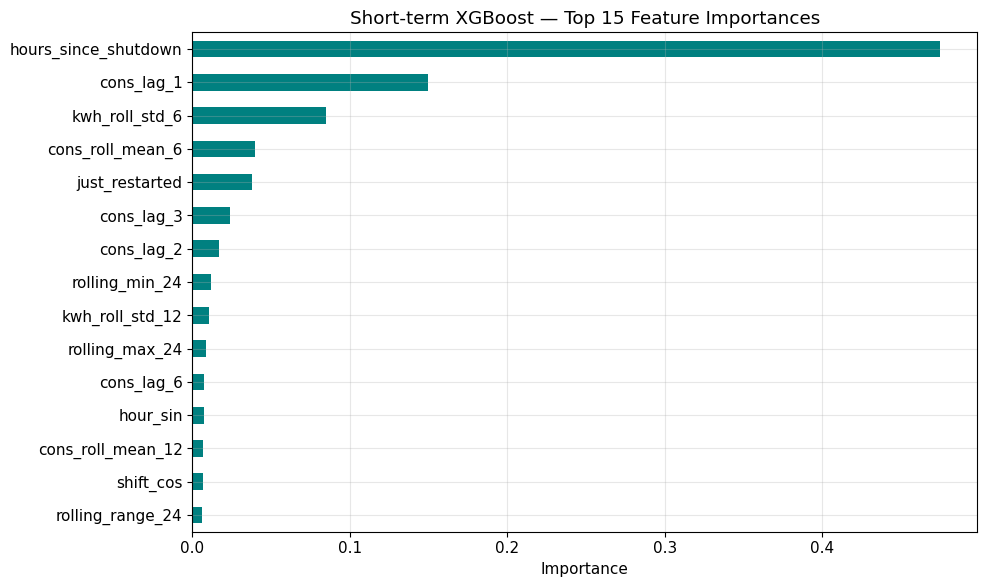

In [11]:
# Feature importance — validates that lag features (cons_lag_1, cons_lag_24) dominate,
# confirming why the short-term model works well for near-term but degrades recursively
imp = pd.Series(xgb_hourly.feature_importances_, index=HOURLY_FEATURES).sort_values(ascending=True)
imp.tail(15).plot.barh(figsize=(10, 6), color="teal")
plt.title("Short-term XGBoost — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Section 6 — DOW Hourly Profiles
7 distinct profiles (one per day-of-week) built from active days only. Falls back to 3 day-type profiles (working/weekend/holiday) for sparse DOWs.

In [12]:
# DOW profiles answer: "given a daily total prediction, how is it distributed across 24 hours?"
# Each hour's fraction of the daily total is averaged across all active days of that DOW.
hourly_full = df.copy()
hourly_full["date"] = hourly_full["rtc_timestamp"].dt.date
hourly_full["hour"] = hourly_full["rtc_timestamp"].dt.hour

daily_totals = hourly_full.groupby("date")["consumption_kwh"].sum().reset_index()
daily_totals.columns = ["date", "daily_total"]

# Only use active days — shutdown days have near-zero totals that would dilute the profiles
active_dates = set(daily_totals.loc[daily_totals["daily_total"] >= SHUTDOWN_THRESH, "date"])

hourly_active = hourly_full[hourly_full["date"].isin(active_dates)].copy()
hourly_active = hourly_active.merge(daily_totals, on="date")
# frac = what proportion of the day's total energy was consumed in this hour
hourly_active["frac"] = hourly_active["consumption_kwh"] / hourly_active["daily_total"].clip(lower=1)

# --- Fallback: 3 coarse day-type profiles (used when a DOW has <4 active day samples) ---
hourly_active["day_type"] = hourly_active["rtc_timestamp"].apply(
    lambda t: "holiday" if t.date() in _gj_holidays
    else ("weekend" if t.dayofweek >= 5 else "working")
)
daytype_profiles = hourly_active.groupby(["day_type", "hour"])["frac"].mean().unstack(level=0).fillna(0)
for col in daytype_profiles.columns:
    s = daytype_profiles[col].sum()
    if s > 0:
        daytype_profiles[col] /= s

# --- Primary: 7 DOW profiles — Mon through Sun each get their own hourly shape ---
# This is more granular than 3 day-types because e.g., Friday may ramp down early while Monday ramps up late
hourly_active["dow_val"] = hourly_active["rtc_timestamp"].dt.dayofweek
dow_profiles = pd.DataFrame(index=range(24))

dow_day_counts = hourly_active.groupby("dow_val")["date"].nunique()
print("Active-day samples per DOW:")
for d in range(7):
    cnt = dow_day_counts.get(d, 0)
    label = dow_names[d]
    print(f"  {label} (dow={d}): {cnt} days {'⚠ fallback' if cnt < MIN_DAYS_FOR_DOW else ''}")

for d in range(7):
    n_days = dow_day_counts.get(d, 0)
    if n_days >= MIN_DAYS_FOR_DOW:
        profile = hourly_active[hourly_active["dow_val"] == d].groupby("hour")["frac"].mean()
        profile = profile.reindex(range(24), fill_value=0)
    else:
        if d >= 5:
            profile = daytype_profiles.get("weekend", daytype_profiles.iloc[:, 0])
        else:
            profile = daytype_profiles.get("working", daytype_profiles.iloc[:, 0])

    s = profile.sum()
    if s > 0:
        profile = profile / s
    dow_profiles[d] = profile.values

print(f"\nDOW profiles shape: {dow_profiles.shape}")
print(f"Day-type profiles shape: {daytype_profiles.shape}")
print(f"\nDay-type profiles (fractions summing to 1.0 per column):")
print(daytype_profiles.round(4).to_string())

Active-day samples per DOW:
  Mon (dow=0): 60 days 
  Tue (dow=1): 64 days 
  Wed (dow=2): 68 days 
  Thu (dow=3): 70 days 
  Fri (dow=4): 69 days 
  Sat (dow=5): 64 days 
  Sun (dow=6): 49 days 

DOW profiles shape: (24, 7)
Day-type profiles shape: (24, 3)

Day-type profiles (fractions summing to 1.0 per column):
day_type  holiday  weekend  working
hour                               
0          0.0589   0.0938   0.0441
1          0.0533   0.0796   0.0425
2          0.0395   0.0543   0.0380
3          0.0443   0.0562   0.0400
4          0.0395   0.0534   0.0399
5          0.0369   0.0499   0.0411
6          0.0396   0.0462   0.0416
7          0.0343   0.0461   0.0402
8          0.0351   0.0462   0.0391
9          0.0393   0.0433   0.0408
10         0.0362   0.0346   0.0400
11         0.0304   0.0288   0.0383
12         0.0330   0.0299   0.0380
13         0.0341   0.0298   0.0376
14         0.0417   0.0292   0.0382
15         0.0473   0.0319   0.0413
16         0.0455   0.0317   0.0434


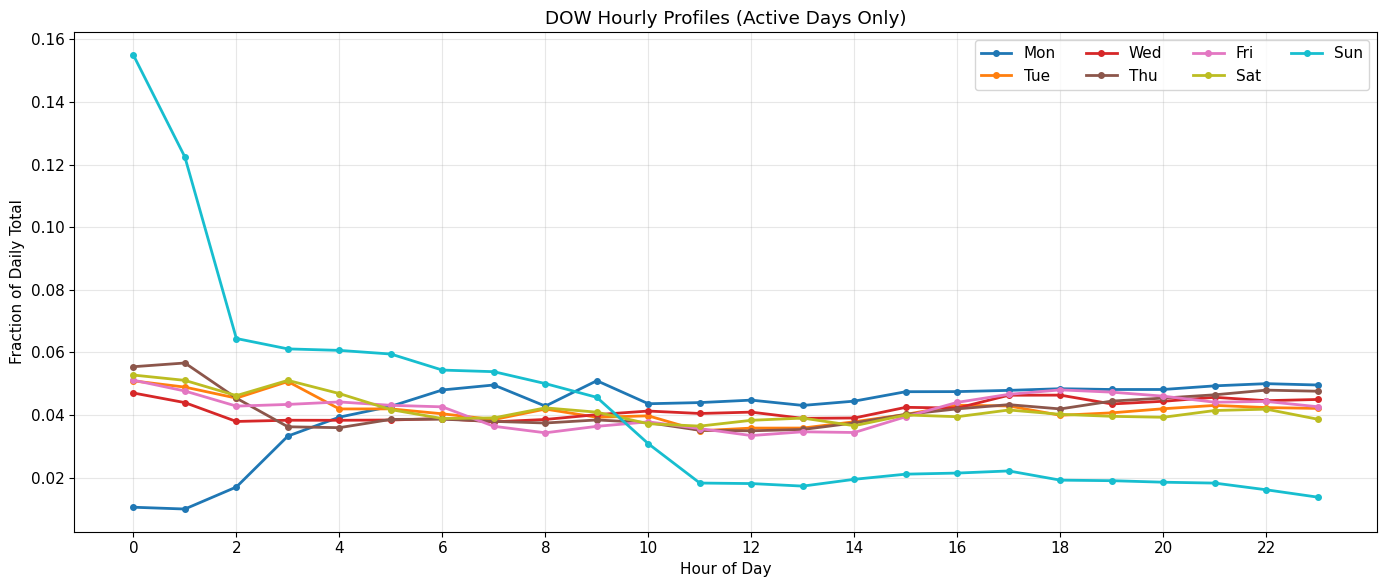

In [13]:
# Visualize all 7 DOW profiles — differences between days validate the choice of
# 7 profiles over 3 coarse day-types. Look for: Fri afternoon ramp-down, Mon morning ramp-up,
# Sat/Sun flat vs weekday peaks.
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 7))
for d in range(7):
    ax.plot(range(24), dow_profiles[d].values, marker="o", ms=4, label=dow_names[d],
            color=colors[d], lw=2)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Fraction of Daily Total")
ax.set_title("DOW Hourly Profiles (Active Days Only)")
ax.set_xticks(range(0, 24, 2))
ax.legend(ncol=4, loc="upper right")
plt.tight_layout()
plt.show()

## Section 7 — Two-Stage Daily Model
**Stage 1**: XGBClassifier predicts if a day is active (≥50 kWh) or shutdown.  
**Stage 2**: XGBRegressor trained on active days only predicts consumption magnitude.  
Only **deterministic calendar features** — no recursive lags.

In [14]:
# DETERMINISTIC features only — no lags or rolling stats.
# Prior experiments showed recursive lags caused +67% monthly error through error propagation.
# These features are fully known for any future date, making batch prediction safe.
DAILY_FEATURES = [
    "is_holiday", "is_weekend", "is_working_day",  # calendar (strongest signal for active/shutdown)
    "dow", "dow_sin", "dow_cos",                    # day-of-week (raw + cyclical)
    "month", "mon_sin", "mon_cos",                  # monthly seasonality
    "day_of_month",                                  # captures start/end-of-month patterns
]

daily_df = df.copy()
daily_df["date"] = daily_df["rtc_timestamp"].dt.date
daily_agg = daily_df.groupby("date").agg(
    y=("consumption_kwh", "sum"),
    is_holiday=("is_holiday", "first"),
    is_weekend=("is_weekend", "first"),
    is_working_day=("is_working_day", "first"),
).reset_index()
daily_agg["ds"] = pd.to_datetime(daily_agg["date"])
daily_agg["dow"] = daily_agg["ds"].dt.dayofweek
daily_agg["dow_sin"] = np.sin(2 * np.pi * daily_agg["dow"] / 7)
daily_agg["dow_cos"] = np.cos(2 * np.pi * daily_agg["dow"] / 7)
daily_agg["month"] = daily_agg["ds"].dt.month
daily_agg["mon_sin"] = np.sin(2 * np.pi * daily_agg["month"] / 12)
daily_agg["mon_cos"] = np.cos(2 * np.pi * daily_agg["month"] / 12)
daily_agg["day_of_month"] = daily_agg["ds"].dt.day
# Binary label for the classifier: active (≥50 kWh) vs shutdown (<50 kWh)
daily_agg["is_active"] = (daily_agg["y"] >= SHUTDOWN_THRESH).astype(int)

# Validation: last 31 days — long enough to include multiple weekends and potential holidays
VAL_DAYS = 31
val_start = daily_agg["ds"].max() - timedelta(days=VAL_DAYS - 1)
train_daily = daily_agg[daily_agg["ds"] < val_start].copy()
val_daily = daily_agg[daily_agg["ds"] >= val_start].copy()

print(f"Daily df shape: {daily_agg.shape}")
print(f"Date range: {daily_agg['ds'].min().date()} → {daily_agg['ds'].max().date()}")
print(f"Active days: {daily_agg['is_active'].sum()}/{len(daily_agg)} ({daily_agg['is_active'].mean()*100:.1f}%)")
print(f"\nDaily Train: {train_daily['ds'].min().date()} → {train_daily['ds'].max().date()} | {len(train_daily)} days")
print(f"  Active: {train_daily['is_active'].sum()} | Shutdown: {(~train_daily['is_active'].astype(bool)).sum()}")
print(f"Daily Val : {val_daily['ds'].min().date()} → {val_daily['ds'].max().date()} | {len(val_daily)} days")

Daily df shape: (487, 14)
Date range: 2024-10-23 → 2026-04-10
Active days: 444/487 (91.2%)

Daily Train: 2024-10-23 → 2026-03-10 | 456 days
  Active: 421 | Shutdown: 35
Daily Val : 2026-03-11 → 2026-04-10 | 31 days


In [15]:
# --- Stage 1: Classifier (active vs shutdown) ---
# scale_pos_weight compensates for class imbalance (~90% active vs ~10% shutdown)
# Without it, the classifier under-predicts shutdowns → false negatives → over-prediction
n_active_train = train_daily["is_active"].sum()
n_shutdown_train = len(train_daily) - n_active_train
spw = n_active_train / max(n_shutdown_train, 1)

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)
xgb_clf.fit(train_daily[DAILY_FEATURES], train_daily["is_active"], verbose=False)

train_clf_acc = accuracy_score(train_daily["is_active"], xgb_clf.predict(train_daily[DAILY_FEATURES]))
print(f"Stage 1 — Classifier trained | Train accuracy: {train_clf_acc*100:.1f}%")

# --- Stage 2: Regressor — trained ONLY on active days ---
# Training on all days (including shutdowns at ~0 kWh) would bias the model low.
# By excluding shutdown days, the regressor learns the unimodal active-day distribution.
train_active = train_daily[train_daily["is_active"] == 1]

xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    n_jobs=-1,
)
xgb_reg.fit(train_active[DAILY_FEATURES], train_active["y"], verbose=False)

train_reg_mae = mean_absolute_error(train_active["y"], xgb_reg.predict(train_active[DAILY_FEATURES]))
print(f"Stage 2 — Regressor trained (active days only: {len(train_active)} samples)")
print(f"  Train MAE: {train_reg_mae:.1f} kWh/day")
print(f"  Active-day mean: {train_active['y'].mean():.1f}, median: {train_active['y'].median():.1f} kWh/day")

Stage 1 — Classifier trained | Train accuracy: 95.4%
Stage 2 — Regressor trained (active days only: 421 samples)
  Train MAE: 62.0 kWh/day
  Active-day mean: 517.6, median: 556.4 kWh/day


In [16]:
# --- Validation: Two-stage prediction with hard threshold + recency scaling ---
# Step 1: Get P(active) from classifier
val_probs = xgb_clf.predict_proba(val_daily[DAILY_FEATURES])[:, 1]
# Step 2: Get consumption magnitude from regressor (for all days — but only used if classified active)
val_reg_pred = xgb_reg.predict(val_daily[DAILY_FEATURES]).clip(min=0)

val_daily = val_daily.copy()
val_daily["clf_prob"] = val_probs
# Hard threshold: if P(active) < 0.15, predict 0 kWh (shutdown)
# Soft blending (pred = P * regression) was tried but crushed weekend predictions
val_daily["clf_active"] = (val_probs >= PROB_THRESH).astype(int)
val_daily["pred_raw"] = np.where(val_daily["clf_active"] == 1, val_reg_pred, 0.0)

# Recency scaling: adjusts for drift between full-history training mean and recent consumption
# e.g., if recent 30 active days averaged 400 kWh but full history averaged 530 kWh → ratio ~0.75
recent_active = train_daily[train_daily["is_active"] == 1].tail(RECENT_WINDOW)
recency_ratio = recent_active["y"].mean() / train_active["y"].mean() if len(recent_active) > 0 else 1.0
recency_ratio = np.clip(recency_ratio, 0.5, 1.5)  # guard against extreme ratios

val_daily["pred"] = val_daily["pred_raw"] * recency_ratio

print(f"Recency ratio: {recency_ratio:.3f}")
print(f"Predicted active: {val_daily['clf_active'].sum()}, shutdown: {(val_daily['clf_active'] == 0).sum()}")
print(f"Actual    active: {val_daily['is_active'].sum()}, shutdown: {(val_daily['is_active'] == 0).sum()}")
print(f"\nValidation daily predictions:")
print(val_daily[["ds", "y", "pred", "clf_active", "clf_prob"]].to_string(index=False))

Recency ratio: 0.870
Predicted active: 30, shutdown: 1
Actual    active: 23, shutdown: 8

Validation daily predictions:
        ds          y       pred  clf_active  clf_prob
2026-03-11 421.191687 477.281860           1  0.998288
2026-03-12 442.045718 459.763824           1  0.999768
2026-03-13 350.178531 490.129272           1  0.999780
2026-03-14 284.428571 361.638611           1  0.989298
2026-03-15  20.800000   0.000000           0  0.050832
2026-03-16 305.153333 343.123718           1  0.990800
2026-03-17 182.606667 487.533569           1  0.990922
2026-03-18   0.000000 506.262146           1  0.999666
2026-03-19   0.000000 413.725342           1  0.999643
2026-03-20   0.000000 345.815918           1  0.999681
2026-03-21   0.000000 451.395508           1  0.964957
2026-03-22   0.000000 129.086227           1  0.977319
2026-03-23 359.783099 473.657471           1  0.999400
2026-03-24 632.672330 445.337097           1  0.999423
2026-03-25 526.078085 512.546875           1  0.999461


## Section 8 — 7-Day Forecast Generation
Predict daily totals (hard threshold) → decompose into 24h via DOW profiles → output 168 hourly predictions.

In [17]:
def decompose_daily_to_hourly(daily_pred_df, dow_profiles, daytype_profiles):
    """Decompose daily total predictions into 24 hourly values using DOW profiles.
    
    For each day: hourly_kwh[h] = daily_total * profile[dow][h]
    where profile[dow][h] is the average fraction of daily energy consumed at hour h
    for that day-of-week, learned from active days in the training data.
    
    Falls back to coarser day-type profiles (working/weekend/holiday) if the
    specific DOW profile is unavailable.
    """
    rows = []
    for _, row in daily_pred_df.iterrows():
        d = row["ds"]
        pred_total = row["pred"]
        dow_val = d.dayofweek

        if dow_val in dow_profiles.columns:
            profile = dow_profiles[dow_val].values
        else:
            dt = row.get("day_type", "working")
            profile = daytype_profiles[dt].values if dt in daytype_profiles.columns else daytype_profiles.iloc[:, 0].values

        for h in range(24):
            rows.append({
                "rtc_timestamp": d + timedelta(hours=h),
                "forecast_kwh": pred_total * profile[h],
            })
    return pd.DataFrame(rows)


# --- Retrain on ALL data (train + validation) for production forecasting ---
# The validation split above was only for measuring accuracy; the final models use all available data
xgb_clf_full = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    scale_pos_weight=spw, random_state=42, n_jobs=-1, eval_metric="logloss",
)
xgb_clf_full.fit(daily_agg[DAILY_FEATURES], daily_agg["is_active"], verbose=False)

all_active = daily_agg[daily_agg["is_active"] == 1]
xgb_reg_full = XGBRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1,
)
xgb_reg_full.fit(all_active[DAILY_FEATURES], all_active["y"], verbose=False)

# Recency scaling (using last 30 active days of full dataset)
recent_full = daily_agg[daily_agg["is_active"] == 1].tail(RECENT_WINDOW)
recency_full = recent_full["y"].mean() / all_active["y"].mean()
recency_full = np.clip(recency_full, 0.5, 1.5)
print(f"Full-data recency ratio: {recency_full:.3f}")

# Build future 7-day feature rows
last_date = daily_agg["ds"].max()
future_dates = [last_date + timedelta(days=i + 1) for i in range(FORECAST_DAYS)]
future_daily = pd.DataFrame({"ds": future_dates})
future_daily["is_holiday"] = future_daily["ds"].dt.date.apply(lambda d: 1 if d in _gj_holidays else 0)
future_daily["is_weekend"] = (future_daily["ds"].dt.dayofweek >= 5).astype(int)
future_daily["is_working_day"] = ((future_daily["is_weekend"] == 0) & (future_daily["is_holiday"] == 0)).astype(int)
future_daily["dow"] = future_daily["ds"].dt.dayofweek
future_daily["dow_sin"] = np.sin(2 * np.pi * future_daily["dow"] / 7)
future_daily["dow_cos"] = np.cos(2 * np.pi * future_daily["dow"] / 7)
future_daily["month"] = future_daily["ds"].dt.month
future_daily["mon_sin"] = np.sin(2 * np.pi * future_daily["month"] / 12)
future_daily["mon_cos"] = np.cos(2 * np.pi * future_daily["month"] / 12)
future_daily["day_of_month"] = future_daily["ds"].dt.day

# Predict
fut_probs = xgb_clf_full.predict_proba(future_daily[DAILY_FEATURES])[:, 1]
fut_reg = xgb_reg_full.predict(future_daily[DAILY_FEATURES]).clip(min=0)
future_daily["clf_prob"] = fut_probs
future_daily["clf_active"] = (fut_probs >= PROB_THRESH).astype(int)
future_daily["pred"] = np.where(future_daily["clf_active"] == 1, fut_reg * recency_full, 0.0)

# Day type for profile lookup
future_daily["day_type"] = future_daily.apply(
    lambda r: "holiday" if r["is_holiday"] else ("weekend" if r["is_weekend"] else "working"), axis=1
)

print(f"\n{'═' * 60}")
print(f"7-DAY FORECAST (from {future_dates[0].date()} to {future_dates[-1].date()})")
print(f"{'═' * 60}")
print(f"{'Date':<12} {'DOW':<5} {'Type':<9} {'P(active)':<10} {'Pred kWh':<10}")
print(f"{'-' * 46}")
for _, r in future_daily.iterrows():
    print(f"{r['ds'].date()!s:<12} {dow_names[r['dow']]:<5} {r['day_type']:<9} {r['clf_prob']:.3f}     {r['pred']:.1f}")
print(f"\nWeekly total: {future_daily['pred'].sum():.1f} kWh")

# Decompose into hourly
future_hourly = decompose_daily_to_hourly(future_daily, dow_profiles, daytype_profiles)
print(f"Hourly forecast rows: {len(future_hourly)}")
future_hourly.head(24)

Full-data recency ratio: 0.723

════════════════════════════════════════════════════════════
7-DAY FORECAST (from 2026-04-11 to 2026-04-17)
════════════════════════════════════════════════════════════
Date         DOW   Type      P(active)  Pred kWh  
----------------------------------------------
2026-04-11   Sat   weekend   0.977     308.5
2026-04-12   Sun   weekend   0.975     169.0
2026-04-13   Mon   working   1.000     377.9
2026-04-14   Tue   holiday   0.999     301.3
2026-04-15   Wed   working   0.994     428.4
2026-04-16   Thu   working   0.996     415.8
2026-04-17   Fri   working   0.996     322.7

Weekly total: 2323.5 kWh
Hourly forecast rows: 168


,rtc_timestamp,forecast_kwh
0,2026-04-11 00:00:00,16.274231
1,2026-04-11 01:00:00,15.749906
2,2026-04-11 02:00:00,14.245395
3,2026-04-11 03:00:00,15.750040
4,2026-04-11 04:00:00,14.448030
5,2026-04-11 05:00:00,12.865237
6,2026-04-11 06:00:00,11.986279
7,2026-04-11 07:00:00,12.049341
8,2026-04-11 08:00:00,13.040022
9,2026-04-11 09:00:00,12.614549


## Section 9 — Validation Metrics & Plots

In [18]:
# === CLASSIFIER METRICS ===
# TP = correctly predicted shutdown, FP = active day wrongly called shutdown (lost kWh in forecast),
# FN = shutdown day missed (phantom kWh added to forecast)
tp = ((val_daily["clf_active"] == 0) & (val_daily["is_active"] == 0)).sum()
fp = ((val_daily["clf_active"] == 0) & (val_daily["is_active"] == 1)).sum()
fn = ((val_daily["clf_active"] == 1) & (val_daily["is_active"] == 0)).sum()
clf_acc = accuracy_score(val_daily["is_active"], val_daily["clf_active"])

val_active_mask = val_daily["is_active"] == 1
val_active = val_daily[val_active_mask]

daily_mae = mean_absolute_error(val_active["y"], val_active["pred"])
daily_rmse = np.sqrt(mean_squared_error(val_active["y"], val_active["pred"]))
daily_mape = np.mean(np.abs((val_active["y"] - val_active["pred"]) / val_active["y"].clip(lower=1))) * 100

print(f"{'═' * 55}")
print(f"CLASSIFIER (Stage 1)")
print(f"{'═' * 55}")
print(f"Accuracy: {int(clf_acc * len(val_daily))}/{len(val_daily)} ({clf_acc*100:.1f}%)")
print(f"Shutdown detection: TP={tp}, FP={fp}, FN={fn}")

print(f"\n{'═' * 55}")
print(f"DAILY-level metrics (active days only, y > {SHUTDOWN_THRESH} kWh)")
print(f"{'═' * 55}")
print(f"Active days: {val_active_mask.sum()} / {len(val_daily)}")
print(f"MAE  : {daily_mae:.2f} kWh/day")
print(f"RMSE : {daily_rmse:.2f} kWh/day")
print(f"MAPE : {daily_mape:.2f}%")

# === HOURLY DECOMPOSITION ON VALIDATION ===
# Decompose validation daily predictions into hourly, then compare against actual hourly consumption
val_hourly = decompose_daily_to_hourly(val_daily, dow_profiles, daytype_profiles)

val_actual_hourly = df[
    (df["rtc_timestamp"] >= val_daily["ds"].min()) &
    (df["rtc_timestamp"] < val_daily["ds"].max() + timedelta(days=1))
][["rtc_timestamp", "consumption_kwh"]].copy()

val_merged = val_actual_hourly.merge(val_hourly, on="rtc_timestamp", how="inner")

hourly_mae = mean_absolute_error(val_merged["consumption_kwh"], val_merged["forecast_kwh"])
hourly_rmse = np.sqrt(mean_squared_error(val_merged["consumption_kwh"], val_merged["forecast_kwh"]))
active_hrs = val_merged["consumption_kwh"] > ACTIVE_HOUR_THRESH
hourly_mape = np.mean(
    np.abs((val_merged.loc[active_hrs, "consumption_kwh"] - val_merged.loc[active_hrs, "forecast_kwh"])
           / val_merged.loc[active_hrs, "consumption_kwh"])
) * 100

print(f"\n{'═' * 55}")
print(f"HOURLY-level metrics (after decomposition)")
print(f"{'═' * 55}")
print(f"MAE  : {hourly_mae:.2f} kWh/h")
print(f"RMSE : {hourly_rmse:.2f} kWh/h")
print(f"MAPE : {hourly_mape:.2f}% (active hours > {ACTIVE_HOUR_THRESH} kWh, n={active_hrs.sum()})")

# === MONTHLY TOTAL ===
actual_total = val_daily["y"].sum()
pred_total = val_daily["pred"].sum()
total_err_pct = (pred_total - actual_total) / actual_total * 100

print(f"\n{'═' * 55}")
print(f"MONTHLY TOTAL (validation period)")
print(f"{'═' * 55}")
print(f"Actual total    : {actual_total:,.0f} kWh")
print(f"Predicted total : {pred_total:,.0f} kWh")
print(f"Error           : {total_err_pct:+.2f}%")
print(f"Abs difference  : {abs(pred_total - actual_total):,.0f} kWh")

═══════════════════════════════════════════════════════
CLASSIFIER (Stage 1)
═══════════════════════════════════════════════════════
Accuracy: 24/31 (77.4%)
Shutdown detection: TP=1, FP=0, FN=7

═══════════════════════════════════════════════════════
DAILY-level metrics (active days only, y > 50 kWh)
═══════════════════════════════════════════════════════
Active days: 23 / 31
MAE  : 124.29 kWh/day
RMSE : 166.49 kWh/day
MAPE : 49.02%

═══════════════════════════════════════════════════════
HOURLY-level metrics (after decomposition)
═══════════════════════════════════════════════════════
MAE  : 9.86 kWh/h
RMSE : 12.55 kWh/h
MAPE : 30.84% (active hours > 5.0 kWh, n=397)

═══════════════════════════════════════════════════════
MONTHLY TOTAL (validation period)
═══════════════════════════════════════════════════════
Actual total    : 8,957 kWh
Predicted total : 13,298 kWh
Error           : +48.46%
Abs difference  : 4,341 kWh


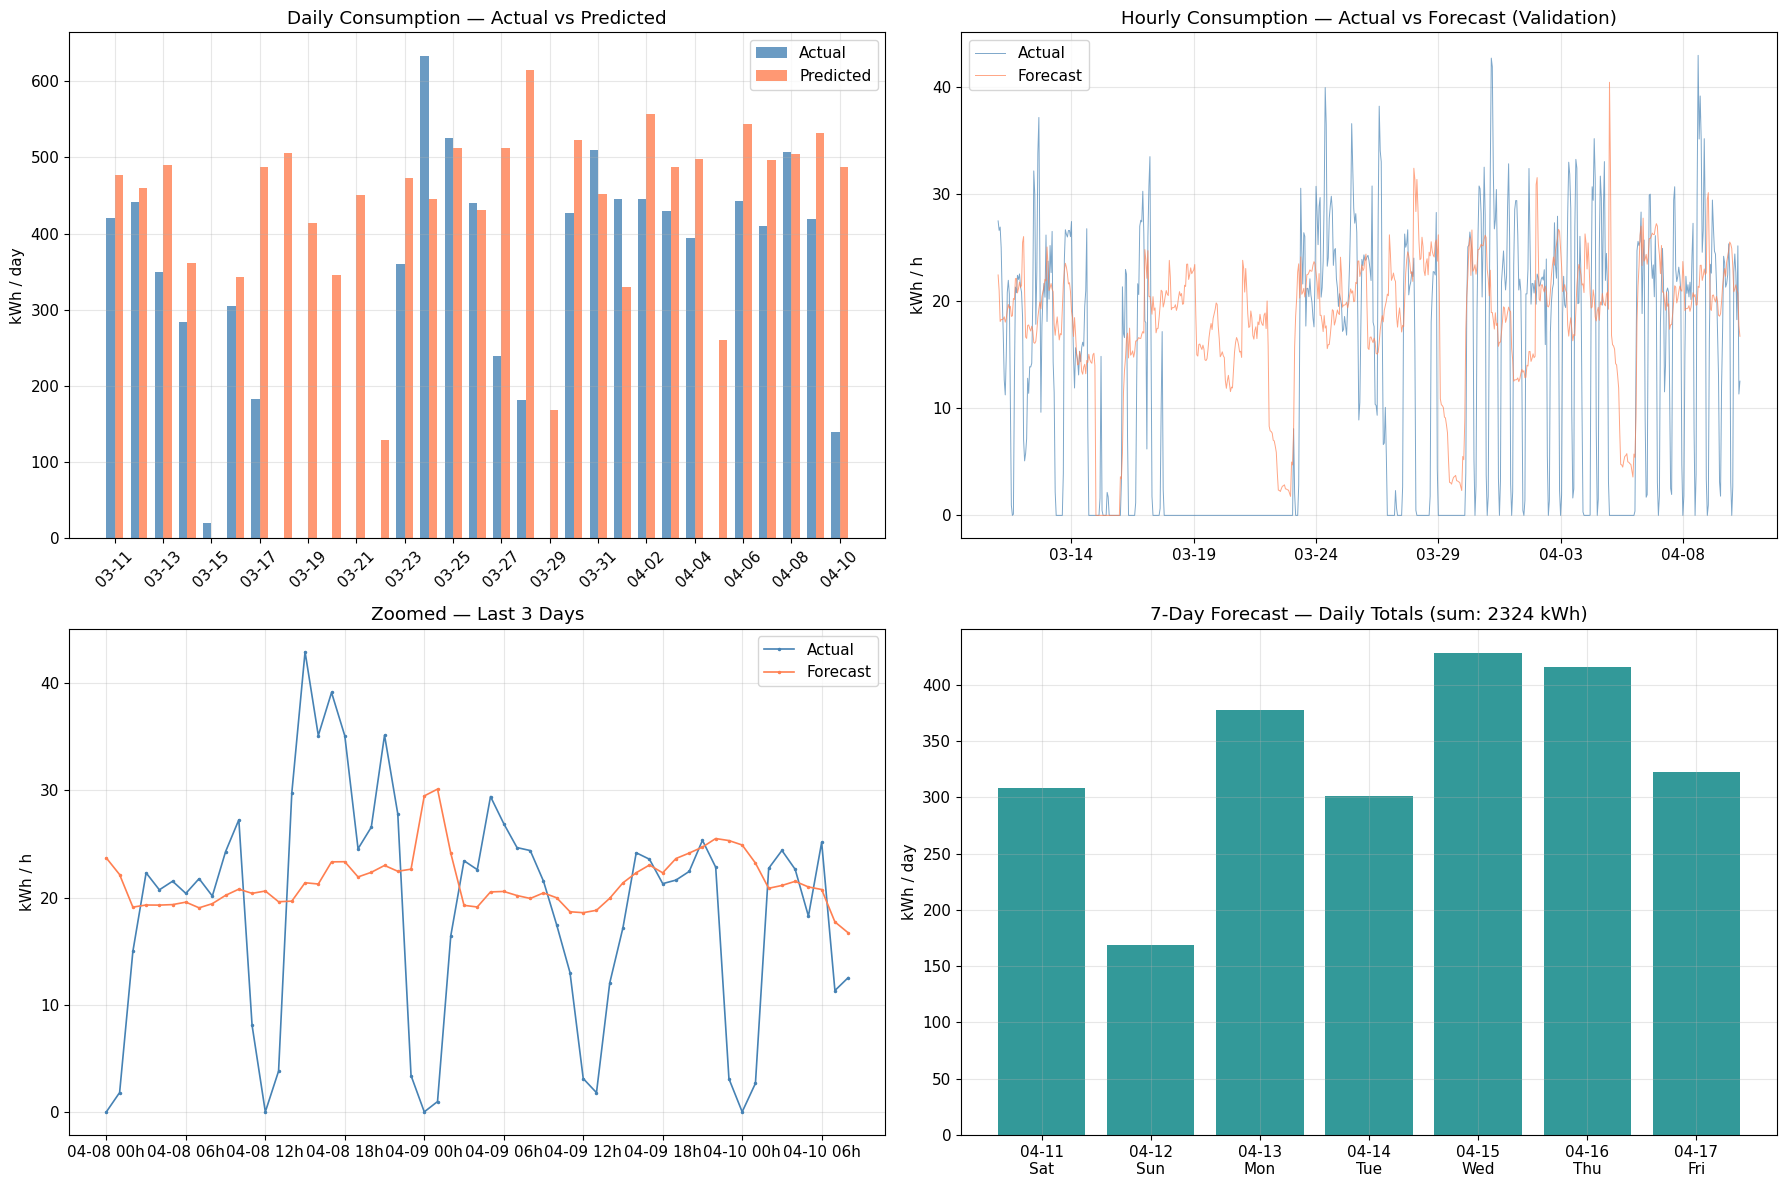

In [19]:
# --- Validation Plots ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 9a — Daily bar chart: actual vs predicted
ax = axes[0, 0]
x = range(len(val_daily))
w = 0.35
ax.bar([i - w/2 for i in x], val_daily["y"], w, label="Actual", color="steelblue", alpha=0.8)
ax.bar([i + w/2 for i in x], val_daily["pred"], w, label="Predicted", color="coral", alpha=0.8)
ax.set_xticks(list(x)[::2])
ax.set_xticklabels([d.strftime("%m-%d") for d in val_daily["ds"]][::2], rotation=45)
ax.set_title("Daily Consumption — Actual vs Predicted")
ax.set_ylabel("kWh / day")
ax.legend()

# 9b — Hourly overlay (full validation period)
ax = axes[0, 1]
ax.plot(val_merged["rtc_timestamp"], val_merged["consumption_kwh"],
        lw=0.7, alpha=0.7, label="Actual", color="steelblue")
ax.plot(val_merged["rtc_timestamp"], val_merged["forecast_kwh"],
        lw=0.7, alpha=0.7, label="Forecast", color="coral")
ax.set_title("Hourly Consumption — Actual vs Forecast (Validation)")
ax.set_ylabel("kWh / h")
ax.legend()
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# 9c — Zoomed last 3 days
last_3d = val_merged[val_merged["rtc_timestamp"] >= val_daily["ds"].max() - timedelta(days=2)]
ax = axes[1, 0]
ax.plot(last_3d["rtc_timestamp"], last_3d["consumption_kwh"],
        marker=".", ms=3, lw=1.2, label="Actual", color="steelblue")
ax.plot(last_3d["rtc_timestamp"], last_3d["forecast_kwh"],
        marker=".", ms=3, lw=1.2, label="Forecast", color="coral")
ax.set_title("Zoomed — Last 3 Days")
ax.set_ylabel("kWh / h")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %Hh"))

# 9d — Forecast: 7-day daily totals
ax = axes[1, 1]
ax.bar(range(FORECAST_DAYS), future_daily["pred"], color="teal", alpha=0.8)
ax.set_xticks(range(FORECAST_DAYS))
ax.set_xticklabels([d.date().strftime("%m-%d\n%a") for d in future_daily["ds"]])
ax.set_title(f"7-Day Forecast — Daily Totals (sum: {future_daily['pred'].sum():.0f} kWh)")
ax.set_ylabel("kWh / day")

plt.tight_layout()
plt.show()

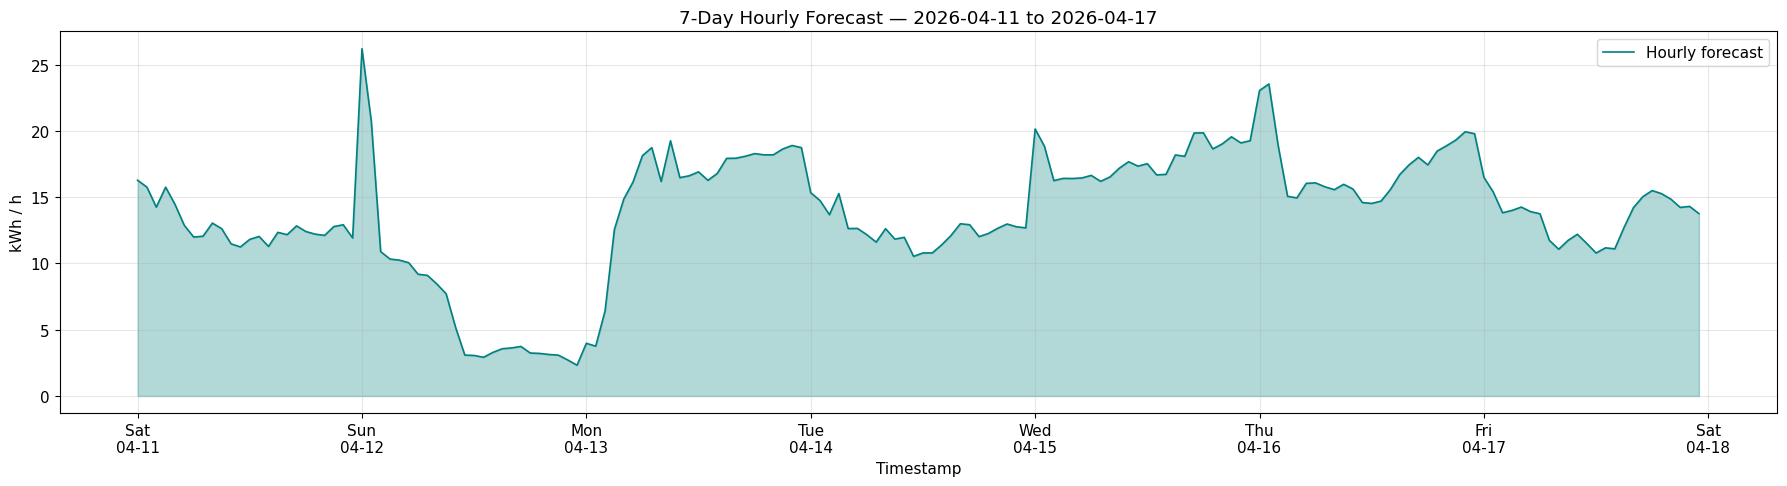

In [20]:
# 7-day hourly forecast plot
fig, ax = plt.subplots(figsize=(18, 5))
ax.fill_between(future_hourly["rtc_timestamp"], future_hourly["forecast_kwh"],
                alpha=0.3, color="teal")
ax.plot(future_hourly["rtc_timestamp"], future_hourly["forecast_kwh"],
        lw=1.2, color="teal", label="Hourly forecast")
ax.set_title(f"7-Day Hourly Forecast — {future_dates[0].date()} to {future_dates[-1].date()}")
ax.set_ylabel("kWh / h")
ax.set_xlabel("Timestamp")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a\n%m-%d"))
ax.legend()
plt.tight_layout()
plt.show()

## Section 10 — Hybrid Short-term Forecast (Next 48h)
- **Hours 1-6**: XGBoost recursive (real lag data available, blended with yesterday's pattern)
- **Hours 7-48**: Two-stage daily model + DOW profile decomposition (hard threshold)
- Smooth handoff blend over hours 4-6

In [21]:
# --- Retrain hourly model on ALL data for production 48h forecasting ---
xgb_hourly_full = XGBRegressor(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, n_jobs=-1,
)
xgb_hourly_full.fit(df[HOURLY_FEATURES], df["consumption_kwh"], verbose=False)
print("Hourly model retrained on full dataset")


def forecast_recursive_6h(model, df_hist, features, n_steps=6):
    """Recursive 1-step forecast for n_steps, blending with yesterday's actual.
    
    At each step:
      1. Build a new row with features computed from the history buffer
      2. Predict next hour's consumption
      3. Blend prediction with yesterday's actual at the same hour (alpha=0.6)
         to prevent recursive convergence to a flat line
      4. Append the blended prediction to the buffer for the next step
    
    The blending is necessary because pure recursive XGBoost predictions
    converge within ~6 steps as lag features become self-referential.
    """
    buf = df_hist.copy()
    preds = []

    for step in range(n_steps):
        last_ts = buf["rtc_timestamp"].iloc[-1]
        next_ts = last_ts + timedelta(hours=1)

        # Append a placeholder row and recompute features from the full buffer
        row = pd.DataFrame({"rtc_timestamp": [next_ts], "total_kwh": [buf["total_kwh"].iloc[-1]],
                            "consumption_kwh": [0.0]})
        row = pd.concat([buf, row], ignore_index=True)
        row = build_features(row)
        row = row.iloc[[-1]]

        pred_cons = float(model.predict(row[features].fillna(0))[0])
        pred_cons = max(pred_cons, 0.0)

        # Yesterday-pattern blending: anchor prediction to actual 24h-ago consumption
        # to preserve daily cycle shape and prevent convergence to flat line
        yesterday_mask = (buf["rtc_timestamp"] == next_ts - timedelta(hours=24))
        if yesterday_mask.any():
            yest_cons = buf.loc[yesterday_mask, "consumption_kwh"].iloc[0]
            alpha = 0.6  # 60% model, 40% yesterday — tuned to balance responsiveness vs stability
            pred_cons = alpha * pred_cons + (1 - alpha) * yest_cons

        # Update the buffer with the blended prediction (so next step's lags use it)
        new_row = pd.DataFrame({
            "rtc_timestamp": [next_ts],
            "total_kwh": [buf["total_kwh"].iloc[-1] + pred_cons],
            "consumption_kwh": [pred_cons],
        })
        buf = pd.concat([buf, new_row], ignore_index=True)
        preds.append({"rtc_timestamp": next_ts, "forecast_kwh": pred_cons})

    return pd.DataFrame(preds)


# --- Build 48h hybrid forecast ---
# Strategy: XGBoost is accurate for 1-6h (real lags available), then hands off to the
# daily model + DOW profiles for 7-48h (where calendar features dominate over lags)
SHORT_TERM_SHUTDOWN_THRESH = 0.15  # same as PROB_THRESH; hard cutoff for daily active/shutdown

# Part A: hours 1-6 — XGBoost recursive (leverages real lag data from last 200 hours)
hist_tail = df.tail(200).copy()
fc_xgb = forecast_recursive_6h(xgb_hourly_full, hist_tail, HOURLY_FEATURES, n_steps=6)

# Part B: hours 7-48 — daily model + DOW profile decomposition
last_ts = df["rtc_timestamp"].max()
last_hour = last_ts.hour

# Determine which calendar days the 7-48h forecast window spans
h7_ts = last_ts + timedelta(hours=7)
h48_ts = last_ts + timedelta(hours=48)

# Build daily features for the spanned days
day_start = h7_ts.normalize()
day_end = h48_ts.normalize()
span_dates = pd.date_range(day_start, day_end, freq="D")

span_daily = pd.DataFrame({"ds": span_dates})
span_daily["is_holiday"] = span_daily["ds"].dt.date.apply(lambda d: 1 if d in _gj_holidays else 0)
span_daily["is_weekend"] = (span_daily["ds"].dt.dayofweek >= 5).astype(int)
span_daily["is_working_day"] = ((span_daily["is_weekend"] == 0) & (span_daily["is_holiday"] == 0)).astype(int)
span_daily["dow"] = span_daily["ds"].dt.dayofweek
span_daily["dow_sin"] = np.sin(2 * np.pi * span_daily["dow"] / 7)
span_daily["dow_cos"] = np.cos(2 * np.pi * span_daily["dow"] / 7)
span_daily["month"] = span_daily["ds"].dt.month
span_daily["mon_sin"] = np.sin(2 * np.pi * span_daily["month"] / 12)
span_daily["mon_cos"] = np.cos(2 * np.pi * span_daily["month"] / 12)
span_daily["day_of_month"] = span_daily["ds"].dt.day
span_daily["day_type"] = span_daily.apply(
    lambda r: "holiday" if r["is_holiday"] else ("weekend" if r["is_weekend"] else "working"), axis=1
)

span_probs = xgb_clf_full.predict_proba(span_daily[DAILY_FEATURES])[:, 1]
span_reg = xgb_reg_full.predict(span_daily[DAILY_FEATURES]).clip(min=0)
span_daily["clf_prob"] = span_probs
span_daily["clf_active"] = (span_probs >= SHORT_TERM_SHUTDOWN_THRESH).astype(int)
span_daily["pred"] = np.where(span_daily["clf_active"] == 1, span_reg * recency_full, 0.0)

# Decompose spanned days into hourly
span_hourly = decompose_daily_to_hourly(span_daily, dow_profiles, daytype_profiles)

# Filter to only hours 7-48
fc_daily_part = span_hourly[
    (span_hourly["rtc_timestamp"] > last_ts + timedelta(hours=6)) &
    (span_hourly["rtc_timestamp"] <= last_ts + timedelta(hours=48))
].copy()

# --- Smooth handoff blend (hours 4-6) ---
# Avoids a hard discontinuity at the XGBoost→daily model boundary.
# Hours 1-3: pure XGBoost, hours 4-6: linear blend (33%/67%/100% daily), hours 7+: pure daily model
blend_rows = []
for step in range(len(fc_xgb)):
    ts = fc_xgb.iloc[step]["rtc_timestamp"]
    xgb_val = fc_xgb.iloc[step]["forecast_kwh"]

    daily_match = span_hourly[span_hourly["rtc_timestamp"] == ts]
    daily_val = daily_match["forecast_kwh"].iloc[0] if len(daily_match) > 0 else xgb_val

    hour_idx = step + 1
    if hour_idx <= 3:
        blend_rows.append({"rtc_timestamp": ts, "forecast_kwh": xgb_val})
    else:
        w = (hour_idx - 3) / 3.0  # 0.33, 0.67, 1.0
        blended = (1 - w) * xgb_val + w * daily_val
        blend_rows.append({"rtc_timestamp": ts, "forecast_kwh": blended})

fc_blended = pd.DataFrame(blend_rows)
fc_48h = pd.concat([fc_blended, fc_daily_part], ignore_index=True)
fc_48h = fc_48h.sort_values("rtc_timestamp").reset_index(drop=True)

print(f"48h hybrid forecast: {len(fc_48h)} hours")
print(f"  From: {fc_48h['rtc_timestamp'].min()}")
print(f"  To  : {fc_48h['rtc_timestamp'].max()}")
print(f"  Total: {fc_48h['forecast_kwh'].sum():.1f} kWh")

# Daily breakdown
fc_48h["date"] = fc_48h["rtc_timestamp"].dt.date
for d, grp in fc_48h.groupby("date"):
    dt_str = pd.Timestamp(d).strftime("%a %Y-%m-%d")
    print(f"  {dt_str}: {grp['forecast_kwh'].sum():.1f} kWh ({len(grp)} hours)")

Hourly model retrained on full dataset
48h hybrid forecast: 48 hours
  From: 2026-04-10 09:00:00
  To  : 2026-04-12 08:00:00
  Total: 573.7 kWh
  Fri 2026-04-10: 150.1 kWh (15 hours)
  Sat 2026-04-11: 308.5 kWh (24 hours)
  Sun 2026-04-12: 115.1 kWh (9 hours)


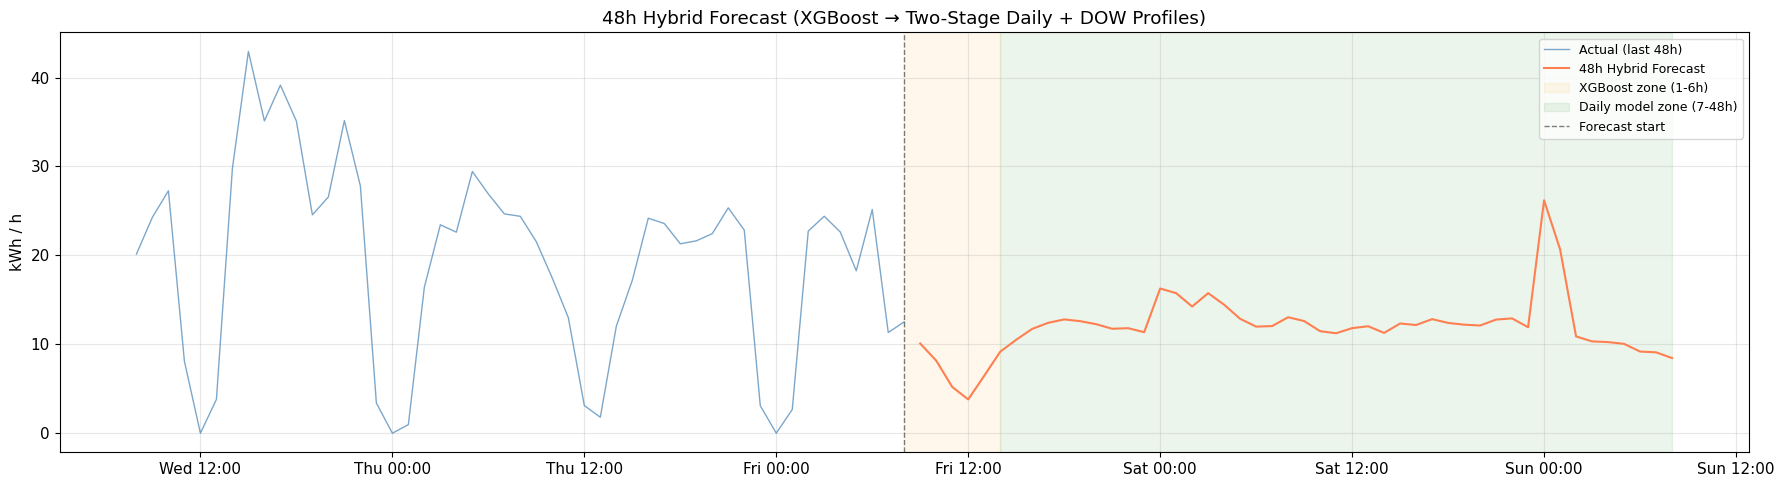

In [22]:
# 48h forecast plot — orange shading = XGBoost zone (hours 1-6), green = daily model zone (7-48)
# The actual last-48h consumption is shown for visual comparison of forecast continuity
fig, ax = plt.subplots(figsize=(18, 5))

# Recent 48h of actual for context
context_start = last_ts - timedelta(hours=48)
context = df[df["rtc_timestamp"] >= context_start][["rtc_timestamp", "consumption_kwh"]]
ax.plot(context["rtc_timestamp"], context["consumption_kwh"],
        lw=1, color="steelblue", alpha=0.7, label="Actual (last 48h)")

# Forecast
ax.plot(fc_48h["rtc_timestamp"], fc_48h["forecast_kwh"],
        lw=1.5, color="coral", label="48h Hybrid Forecast")

# Shade XGBoost zone (1-6h) vs Daily model zone (7-48h)
xgb_end = last_ts + timedelta(hours=6)
ax.axvspan(last_ts, xgb_end, alpha=0.08, color="orange", label="XGBoost zone (1-6h)")
ax.axvspan(xgb_end, fc_48h["rtc_timestamp"].max(), alpha=0.08, color="green", label="Daily model zone (7-48h)")
ax.axvline(last_ts, color="black", ls="--", lw=1, alpha=0.5, label="Forecast start")

ax.set_title("48h Hybrid Forecast (XGBoost → Two-Stage Daily + DOW Profiles)")
ax.set_ylabel("kWh / h")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))
plt.tight_layout()
plt.show()

## Section 11 — Save Artifacts

In [ ]:
# --- Save trained models (full-data refit for production use) ---
joblib.dump(xgb_clf_full, os.path.join(MODEL_DIR, "xgb_clf.pkl"))     # Stage 1: active/shutdown classifier
joblib.dump(xgb_reg_full, os.path.join(MODEL_DIR, "xgb_reg.pkl"))     # Stage 2: daily consumption regressor
joblib.dump(xgb_hourly_full, os.path.join(MODEL_DIR, "xgb_hourly.pkl"))  # Short-term hourly model

# --- Save profiles (needed at inference to decompose daily → hourly) ---
dow_profiles.to_csv(os.path.join(MODEL_DIR, "dow_profiles.csv"), index=True)
daytype_profiles.to_csv(os.path.join(MODEL_DIR, "daytype_profiles.csv"), index=True)

# --- Save forecast outputs (can be loaded by downstream dashboards/APIs) ---
future_daily.to_csv(os.path.join(MODEL_DIR, "future_daily.csv"), index=False)
future_hourly.to_csv(os.path.join(MODEL_DIR, "future_hourly.csv"), index=False)
fc_48h.to_csv(os.path.join(MODEL_DIR, "forecast_48h.csv"), index=False)

print(f"All artifacts saved to: {MODEL_DIR}")
print(f"\nFiles:")
for f in sorted(os.listdir(MODEL_DIR)):
    size = os.path.getsize(os.path.join(MODEL_DIR, f))
    print(f"  {f:<25s} {size / 1024:.1f} KB")

In [23]:
# --- Summary ---
print("=" * 60)
print("ENERGY FORECAST v2 — SUMMARY")
print("=" * 60)
print(f"Meter          : {METER_ID}")
print(f"Data range     : {df['rtc_timestamp'].min().date()} → {df['rtc_timestamp'].max().date()}")
print(f"Hourly rows    : {len(df):,}")
print(f"Daily days     : {len(daily_agg)}")
print(f"Active / total : {daily_agg['is_active'].sum()} / {len(daily_agg)}")
print()
print("Validation (last 31 days):")
print(f"  Daily MAE  : {daily_mae:.1f} kWh/day")
print(f"  Daily MAPE : {daily_mape:.1f}%")
print(f"  Hourly MAE : {hourly_mae:.1f} kWh/h")
print(f"  Hourly MAPE: {hourly_mape:.1f}%")
print(f"  Total error: {total_err_pct:+.1f}%")
print()
print(f"7-day forecast : {future_daily['pred'].sum():.0f} kWh")
print(f"48h forecast   : {fc_48h['forecast_kwh'].sum():.0f} kWh")
print(f"Artifacts saved: {MODEL_DIR}")

ENERGY FORECAST v2 — SUMMARY
Meter          : FUTU0000000004000002
Data range     : 2024-10-23 → 2026-04-10
Hourly rows    : 11,075
Daily days     : 487
Active / total : 444 / 487

Validation (last 31 days):
  Daily MAE  : 124.3 kWh/day
  Daily MAPE : 49.0%
  Hourly MAE : 9.9 kWh/h
  Hourly MAPE: 30.8%
  Total error: +48.5%

7-day forecast : 2324 kWh
48h forecast   : 574 kWh
Artifacts saved: E:\Projects\IOT-AI-Implementation\models\MODEL02_v2
